In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, roc_curve, roc_auc_score, jaccard_score)

In [14]:
data = pd.read_csv("samples_cancer.csv")

In [15]:
if 'ID' in data.columns:
    data = data.drop(columns=['ID'])
data = data[data['BareNuc'] != '?'].copy()
data['BareNuc'] = data['BareNuc'].astype(int)

In [16]:
data['Class'] = data['Class'].map({2: 0, 4: 1})

In [17]:
X = data.drop(columns=['Class'])
y = data['Class']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
kernels = {
    'linear': {'kernel': 'linear', 'C': 1.0},
    'poly'  : {'kernel': 'poly',   'degree': 3, 'C': 1.0},
    'rbf'   : {'kernel': 'rbf',    'C': 1.0, 'gamma': 'scale'},
    'sigmoid':{'kernel': 'sigmoid','C': 1.0, 'gamma': 'scale'}
}

results = {}

In [21]:
for name, params in kernels.items():

    svc = SVC(probability=True, random_state=42, **params)
    svc.fit(X_train_scaled, y_train)

    y_pred = svc.predict(X_test_scaled)
    y_score = svc.predict_proba(X_test_scaled)[:, 1]  # probability for positive class

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    jacc = jaccard_score(y_test, y_pred, zero_division=0)
    err_rate = 1.0 - acc
    cm = confusion_matrix(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_val = roc_auc_score(y_test, y_score)

    results[name] = {
        'model': svc,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'jaccard': jacc,
        'error_rate': err_rate,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'auc': auc_val
    }

In [22]:
for name, res in results.items():
    print(f"\n--- SVM ({name}) ---")
    print(f"Accuracy   : {res['accuracy']:.4f}")
    print(f"Recall     : {res['recall']:.4f}")
    print(f"Precision  : {res['precision']:.4f}")
    print(f"F1-Score   : {res['f1']:.4f}")
    print(f"Jaccard    : {res['jaccard']:.4f}")
    print(f"Error Rate : {res['error_rate']:.4f}")
    print("Confusion Matrix:\n", res['confusion_matrix'])
    print(f"AUC        : {res['auc']:.4f}")


--- SVM (linear) ---
Accuracy   : 0.9562
Recall     : 0.9583
Precision  : 0.9200
F1-Score   : 0.9388
Jaccard    : 0.8846
Error Rate : 0.0438
Confusion Matrix:
 [[85  4]
 [ 2 46]]
AUC        : 0.9918

--- SVM (poly) ---
Accuracy   : 0.9562
Recall     : 0.9167
Precision  : 0.9565
F1-Score   : 0.9362
Jaccard    : 0.8800
Error Rate : 0.0438
Confusion Matrix:
 [[87  2]
 [ 4 44]]
AUC        : 0.9927

--- SVM (rbf) ---
Accuracy   : 0.9635
Recall     : 0.9792
Precision  : 0.9216
F1-Score   : 0.9495
Jaccard    : 0.9038
Error Rate : 0.0365
Confusion Matrix:
 [[85  4]
 [ 1 47]]
AUC        : 0.9759

--- SVM (sigmoid) ---
Accuracy   : 0.9416
Recall     : 0.9167
Precision  : 0.9167
F1-Score   : 0.9167
Jaccard    : 0.8462
Error Rate : 0.0584
Confusion Matrix:
 [[85  4]
 [ 4 44]]
AUC        : 0.9731


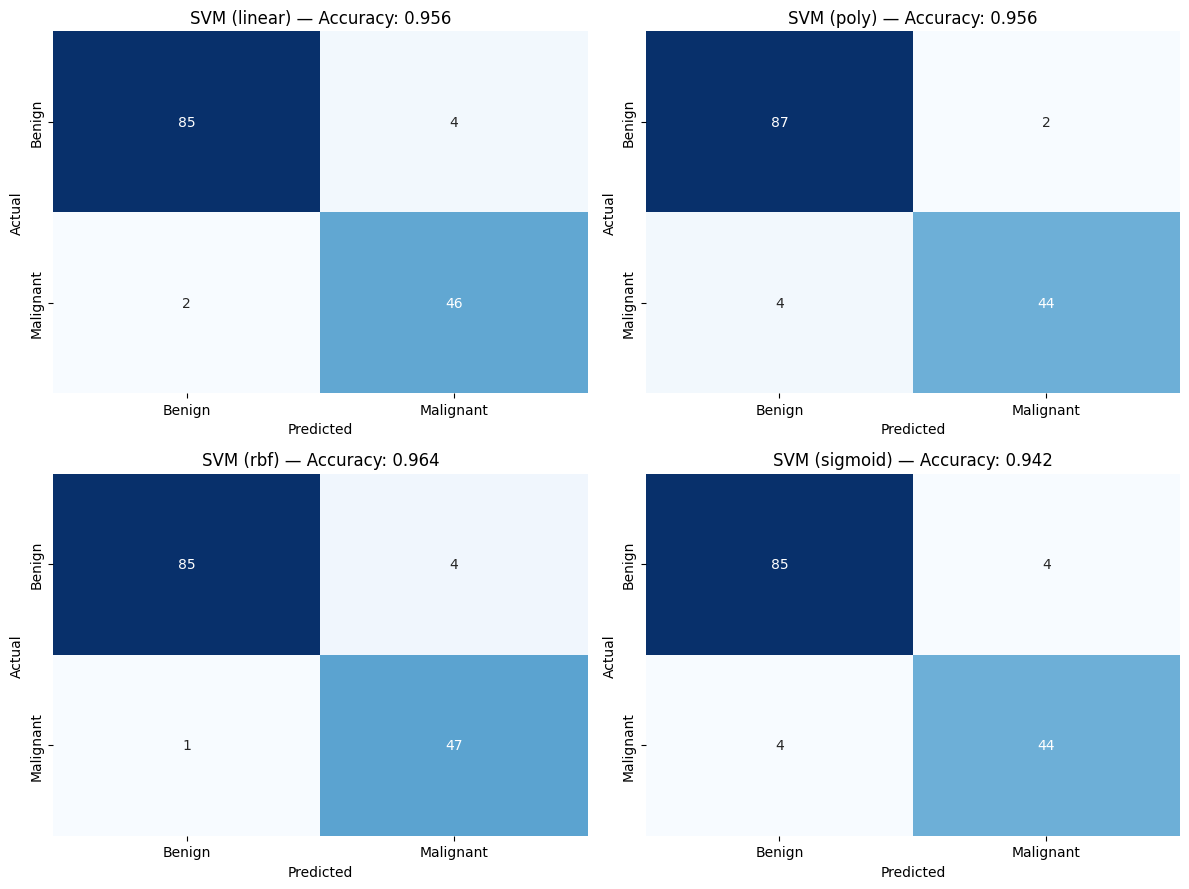

In [23]:
plt.figure(figsize=(12, 9))
for i, (name, res) in enumerate(results.items(), 1):
    ax = plt.subplot(2, 2, i)
    cm = res['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'], ax=ax)
    ax.set_title(f"SVM ({name}) — Accuracy: {res['accuracy']:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

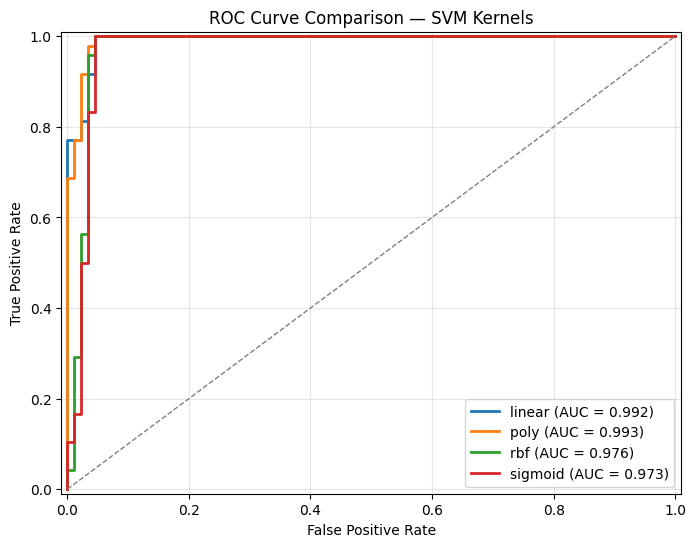

In [24]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], lw=2, label=f"{name} (AUC = {res['auc']:.3f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — SVM Kernels')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()